## Data Exploration and Cleaning

[Mendeley - Steam Games Metadata and Player Reviews](https://data.mendeley.com/datasets/jxy85cr3th/2)

**Sampling**

In [11]:
import pandas as pd
import json
import os
import re
import csv
from langdetect import detect, LangDetectException
import matplotlib.pyplot as plt

In [ ]:
# Reduce Mendeley games.json to game id and name only
# ALREADY EXIST AS ../cleaned_data/mendeley_id_to_name.json
input_path = '../data/mendeley/games.json'
output_path = '../data/mendeley/games_reduced.json'
with open(input_path, 'r', encoding='utf-8') as f:
    games_data = json.load(f)
reduced_games = {}
for game_id, info in games_data.items():
    if game_id in reduced_games:
        print(f"Duplicate game ID found: {game_id}")
    reduced_games[game_id] = info['name']
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(reduced_games, f, indent=2)

In [ ]:
# Will take ~2 hours - NOT YET RUN TO FINISH
# Create spreadsheet of game files in categories:
# - total reviews
# - positive ratio

all_game_stats  = {}
games_collected = 0
files_created = 0

for game_file in os.listdir('../data/Mendeley/reviews/'):
    game_id = game_file.split('_')[0]    # file name is id_num-of-reviews.csv
    with open(os.path.join('../data/Mendeley/reviews/', game_file), 'r', encoding='utf-8') as f:
        game_df = pd.read_csv(f)
    
    total_reviews = len(game_df)
    positive_reviews = sum(1 for _, row in game_df.iterrows() if row['recommend'] == "Recommended")
    pos_ratio = positive_reviews / total_reviews if total_reviews > 0 else 0
    all_game_stats[game_id] = {
        'tot_reviews': total_reviews,
        'pos_reviews': positive_reviews,
        'pos_ratio':  pos_ratio,
    }
    games_collected += 1
    if games_collected % 660 == 0:
        print(f"Processed {games_collected} games")
    # flush progress every 6600 games
    if games_collected % 6600 == 0:
        print(f"Collected stats for {games_collected} games")
        with open(f'../data/Mendeley/game_stats/info{files_created}.json', 'w', encoding='utf-8') as f:
                json.dump(all_game_stats, f, indent=2)
        files_created += 1
        all_game_stats = {}

Processed 660 games


KeyboardInterrupt: 

In [ ]:
# Record game id to number of review based on file naming
# ALREADY EXIST AS ../cleaned_data/mendeley_id_to_review_num.csv
num_review_data = [['id', 'num_reviews']]

for game_file in os.listdir('../data/Mendeley/reviews/'):
    combined_name = game_file.strip('.csv')
    game_id, num_reviews = combined_name.split('_')
    num_review_data.append([game_id, num_reviews])

with open('../data/Mendeley/game_stats/num_reviews.csv', 'w', encoding='utf-8', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(num_review_data)

Most reviews: 336460
Least reviews: 26
Average reviews: 1377.608
Median reviews: 100.0


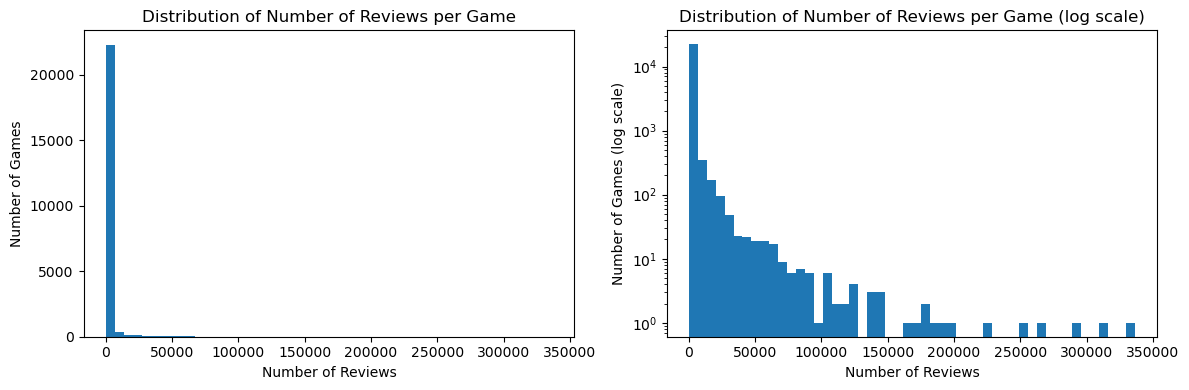

In [25]:
# Graph distribution of number of reviews
with open('../data/Mendeley/game_stats/num_reviews.csv', 'r', encoding='utf-8') as f:
    num_reviews_df = pd.read_csv(f)
print(f"Most reviews: {num_reviews_df['num_reviews'].max()}")
print(f"Least reviews: {num_reviews_df['num_reviews'].min()}")
print(f"Average reviews: {num_reviews_df['num_reviews'].mean():.3f}")
print(f"Median reviews: {num_reviews_df['num_reviews'].median()}")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(num_reviews_df['num_reviews'], bins=50, log=True)
axes[0].set_yscale("linear")
axes[0].set_title('Distribution of Number of Reviews per Game')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Number of Games')
axes[1].hist(num_reviews_df['num_reviews'], bins=50)
axes[1].set_yscale("log")
axes[1].set_title('Distribution of Number of Reviews per Game (log scale)')
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Number of Games (log scale)')

plt.tight_layout()
plt.show()

In [60]:
# ========== Sample Generation ==========
def sample_games_by_review_count(min_reviews, max_reviews, sample_size, seed=None) -> list[str]:
    # Given a range of review counts, sample a number of games within that range.
    with open('../cleaned_data/mendeley_id_to_review_num.csv', 'r', encoding='utf-8') as f:
        num_reviews_df = pd.read_csv(f)
    filtered_games = num_reviews_df[
        (num_reviews_df['num_reviews'] >= min_reviews) &
        (num_reviews_df['num_reviews'] <= max_reviews)
    ]
    if seed:
        sampled_games = filtered_games.sample(n=sample_size, random_state=seed)
    else:
        sampled_games = filtered_games.sample(n=sample_size)
    csv_file_paths = sampled_games['id'].astype(str) + '_'+ sampled_games['num_reviews'].astype(str) + '.csv'
    return csv_file_paths.tolist()

def resolve_id_to_name(game_id: str) -> str:
    with open('../cleaned_data/mendeley_id_to_name.json', 'r', encoding='utf-8') as f:
        games_id_to_name = json.load(f)
    return games_id_to_name.get(game_id, "Unknown Game")

# Sanity test
sampled_files = sample_games_by_review_count(100000, 300000, 5)
print("CSV file format <game_id>_<num_reviews>.csv")
print("Sampled game files:")
for file_name in sampled_files:
    game_name = resolve_id_to_name(file_name.split('_')[0])
    print(f"{file_name} ({game_name})")

CSV file format <game_id>_<num_reviews>.csv
Sampled game files:
2050650_104398.csv (Resident Evil 4)
304390_146029.csv (FOR HONOR™)
1599340_201079.csv (Lost Ark)
1817070_101951.csv (Marvel’s Spider-Man Remastered)
2073850_140640.csv (THE FINALS)
